Imports and loading data

In [1]:
from matplotlib import pyplot as plt
import conntility
import numpy
import pandas
import tqdm

from scipy.spatial.distance import pdist, squareform

path = "/Users/mwr/Documents/artefacts/connectomes/Human connectivity paper/Human_NEWfunct_conmat_filtered_compressed.h5"

M = conntility.ConnectivityMatrix.from_h5(path)
M.vertices

,index,population,node_ids,etype,layer,morphology,mtype,synapse_class,x,y,z,ss_flat_x,depth,ss_flat_y
0,0,hncx_neurons,0,PYR_L23,L2,dend-1490_H22.29.223.11.01.02_withcontour_L2_a...,L2_PTPC,EXC,786.699926,2252.921593,1533.098585,1274.699926,355.078407,1557.098585
1,1,hncx_neurons,1,PYR_L23,L2,dend-770658546_L2_axon-689323433_L2_-_Scale_x1...,L2_PTPC,EXC,1073.068353,2244.681839,867.538846,1561.068353,363.318161,891.538846
2,6,hncx_neurons,6,PYR_L23,L2,dend-770275864_L2_axon-689323433_L2_-_Scale_x1...,L2_PTPC,EXC,613.688828,2088.131741,1374.885965,1101.688828,519.868259,1398.885965
3,11,hncx_neurons,11,PYR_L23,L2,dend-707828926_L2_axon-665713811_L2,L2_PTPC,EXC,759.516508,2230.168256,993.011974,1247.516508,377.831744,1017.011974
4,12,hncx_neurons,12,PYR_L23,L2,dend-707828926_L2_axon-0991_H42-06_L2_-_Scale_...,L2_PTPC,EXC,815.300840,2241.759914,1247.501864,1303.300840,366.240086,1271.501864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20059,106652,hncx_neurons,106652,PYR_L23,L3b,dend-1277_H42_01_(left)_L2_L3_axon-595572609_L...,L3_PC,EXC,928.771581,1589.092459,863.493135,1416.771581,1018.907541,887.493135
20060,106654,hncx_neurons,106654,PYR_L23,L3b,dend-475_H23.29.244.11.31.01_withcontour_L2_L3...,L3_PC,EXC,353.669309,1468.544587,955.963045,841.669309,1139.455413,979.963045
20061,106656,hncx_neurons,106656,PYR_L23,L3b,dend-0925_Rhi13313cell1+2(superficial)_L2_L3_a...,L3_PC,EXC,214.277789,1480.560188,1397.907266,702.277789,1127.439812,1421.907266
20062,106659,hncx_neurons,106659,PYR_L23,L3b,dend-0925_Rhi13313cell1+2(superficial)_L2_L3_a...,L3_PC,EXC,616.886630,1440.170760,1338.233403,1104.886630,1167.829240,1362.233403


Performing in-silico patch-sampling

In [5]:
n_patch=12
n_samples=200
slice_thickness=200
mv_cv = numpy.array([[145**2, 0], [0, 150**2]])
col_slc = ["slice_x", "slice_y"]

def value_deltas(values):
    values = values.to_numpy()
    deltas = values.reshape((-1, 1)) - values.reshape((1, -1))
    return deltas.flatten()

results_dfs = []
for _ in tqdm.tqdm(range(n_samples)):
    try:
        s = M.slice(numpy.random.rand() * numpy.pi, (numpy.random.rand() - 0.5) * 50, slice_thickness)
        s = s.patch_sample(n_patch, [0, 0], mv_cv, columns_xy=col_slc)

        results_dfs.append(pandas.DataFrame(
            {
                "dx": value_deltas(s.vertices["x"]),
                "dy": value_deltas(s.vertices["y"]),
                "dz": value_deltas(s.vertices["z"]),
                "synapses": s.array.flatten(),
                "synapses_rec": s.to_reciprocal().array.flatten()
            }
        ))
    except:
        pass

DF = pandas.concat(results_dfs, axis=0).reset_index(drop=True)
DF

100%|██████████| 200/200 [00:15<00:00, 12.79it/s]


,dx,dy,dz,synapses,synapses_rec
0,0.000000,0.000000,0.000000,0,0
1,-50.828787,-23.929889,-345.584414,0,0
2,-31.682345,-106.807825,-77.726371,0,0
3,-96.322139,86.133217,-163.193896,0,0
4,-121.308595,-39.187913,-193.994149,0,0
...,...,...,...,...,...
28795,-8.965026,41.375412,85.210725,0,0
28796,-42.118532,26.369505,-32.589485,0,0
28797,-7.968742,45.335815,13.745866,0,0
28798,-42.720757,46.040453,91.051655,0,0


Creating spatial bins

In [6]:
binning = {
    "vertical": {
        "column": "dy",
        "number": 7,
        "size": 50.0,
        "abs": False
    },
    "horizontal": {
        "column": "dx",
        "number": 3,
        "size": 50.0,
        "abs": True
    }
}

def make_bins(specs):
    if not specs["abs"]:
        n = int(specs["number"] / 2)
        bins = (numpy.arange(-n, n + 2) - 0.5) * specs["size"]
    else:
        bins = numpy.arange(specs["number"] + 1) * specs["size"]
        bins[0] = 0.01
    return bins

def to_binned(specs, df):
    samples = df[specs["column"]]
    bins = make_bins(specs)
    if specs["abs"]:
        samples = numpy.abs(samples)
    binned = numpy.digitize(samples, bins=bins) - 1
    binned[binned >= (len(bins) - 1)] = -1
    return binned, bins

bins = {}
for dim_name, specs in binning.items():
    DF[dim_name], bins[dim_name] = to_binned(specs, DF)

Plotting

[]

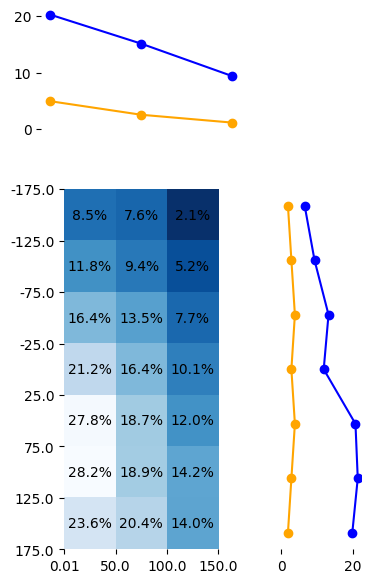

In [7]:
P = DF.groupby(["vertical", "horizontal"])["synapses"].apply(lambda x: (x>0).mean()).unstack().drop(index=-1, columns=-1, errors="ignore")
P_vert = DF.groupby("vertical")["synapses"].apply(lambda x: (x>0).mean()).drop(-1, errors="ignore").sort_index()
P_vert_rec = DF.groupby("vertical")["synapses_rec"].apply(lambda x: (x>0).mean()).drop(-1, errors="ignore").sort_index()
P_hor = DF.groupby("horizontal")["synapses"].apply(lambda x: (x>0).mean()).drop(-1, errors="ignore").sort_index()
P_hor_rec = DF.groupby("horizontal")["synapses_rec"].apply(lambda x: (x>0).mean()).drop(-1, errors="ignore").sort_index()

fig = plt.figure(figsize=(4, 6))

ax = fig.add_axes([0.1, 0.1, 0.5, 0.6])
ax.imshow(P, cmap="Blues_r")

ax.set_yticks(numpy.arange(len(bins["vertical"])) - 0.5)
ax.set_yticklabels(bins["vertical"])
ax.set_xticks(numpy.arange(len(bins["horizontal"])) - 0.5)
ax.set_xticklabels(bins["horizontal"])

for col in P.columns:
    for row in P.index:
        ax.text(col, row, f"{100*P[col][row]:.1f}%",
                horizontalalignment="center",
                verticalalignment="center")
ax.set_frame_on(False)


ax = fig.add_axes([0.7, 0.1, 0.2, 0.6])
w = 0.5 * (bins["vertical"][:-1] + bins["vertical"][1:])
ax.plot(100 * P_vert, w, color="blue", marker="o")
ax.plot(100 * P_vert_rec, w, color="orange", marker="o")
ax.set_ylim(ax.get_ylim()[::-1])
ax.set_xlim([0, numpy.max(ax.get_xlim())])
ax.set_frame_on(False)
ax.set_yticks([])


ax = fig.add_axes([0.1, 0.8, 0.5, 0.2])
w = 0.5 * (bins["horizontal"][:-1] + bins["horizontal"][1:])
ax.plot(w, 100 * P_hor, marker="o", color="blue")
ax.plot(w, 100 * P_hor_rec, marker="o", color="orange")
ax.set_ylim([0, numpy.max(ax.get_ylim())])
ax.set_frame_on(False)
ax.set_xticks([])